# 8.1 ***序列模型***

### 8.1.1 *训练*

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
T = 1000
# time是1*1000的一维向量
time = torch.arange(1, T+1, dtype=torch.float32)
# x也是1*1000的一维向量，是sin函数加上噪声
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))


In [ ]:
tau = 4
# 特征矩阵是(996, 4)，标签矩阵是(996, 1)
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))
# 前600个样本用于训练，每次随机采样16个样本
batch_size, n = 16, 600
train_iter = d2l.load_array((features[:n], labels[:n]),
                             batch_size, is_train=True)

In [ ]:
def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(4, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weight)
    return net

loss = nn.MSELoss(reduction='none')

In [ ]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')
        
net = get_net()
train(net, train_iter, loss, epochs=5, lr=0.01)

# 8.1.2 *预测*

In [ ]:
# 单步预测：只预测下一个时间步的值
# 也就是说，只能得到一个紧邻序列末尾的下一个时间步预测值
# 在下图中，是在全部时间步真实值已知的情况下，才能计算出全部单步预测值的集合
onestep_preds = net(features)
d2l.plot([time, time[tau:]], 
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000],
         figsize=(6, 3))

In [ ]:
# k步预测：对于直到第t步的观测序列，在其时间步t+k处的预测值称为k步预测
multistep_preds = torch.zeros(T)
multistep_preds[: n + tau] = x[: n + tau]
# 从n+tau个时间步开始，要用自己的预测值来预测下一个时间步的值
for i in range(n + tau, T):
    multistep_preds[i] = net(multistep_preds[i - tau:i].reshape((1, -1)))

In [ ]:
d2l.plot([time, time[tau:], time[n + tau:]], 
         [x.detach().numpy(), onestep_preds.detach().numpy(),
          multistep_preds[n + tau:].detach().numpy()], 'time',
         'x', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))

In [ ]:
max_steps = 64

features = torch.zeros((T -tau - max_steps + 1, tau + max_steps))
for i in range(tau):
    features[:, i] = x[i: i + T - tau - max_steps + 1]

for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

In [ ]:
step = (1, 4, 16, 64)

d2l.plot([time[tau + i - 1: T - max_steps + i] for i in step],
         [features[:, (tau + i - 1)].detach().numpy() for i in step], 'time', 'x',
         legend=[f'{i}-step preds' for i in step], xlim=[5, 1000],
         figsize=(6, 3))

# 8.2 *文本预处理*

读取文本，拆分成词元，根据词表将文本映射成数字索引

In [ ]:
import collections
import re
from d2l import torch as d2l

### 8.2.1 *读取数据集*

In [ ]:
d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt'
                                ,'090b5e7e70c295757f55df93cb0a180b9691891a')

lines = d2l.read_time_machine()
print(f'# 文本总行数: {len(lines)}')

### 8.2.2 *词元化*

In [ ]:
tokens = d2l.tokenize(lines)
for i in range(11):
    print(tokens[i])

### 8.2.3 *词表*

In [ ]:
vocab = d2l.Vocab(tokens)
print(list(vocab.token_to_idx.items())[:10])

In [ ]:
for i in [0,10]:
    print('文本:', tokens[i])
    print('索引:', vocab[tokens[i]])


In [ ]:
corpus, vocab = d2l.load_corpus_time_machine()
len(corpus), len(vocab)

# 8.3 ***语言模型和数据集***

In [ ]:
import random
import torch
from d2l import torch as d2l

In [ ]:
tokens = d2l.tokenize(d2l.read_time_machine())

corpus = [token for line in tokens for token in line]
vocab = d2l.Vocab(corpus)
vocab.token_freqs[:10]

In [ ]:
freqs = [freq for token, freq in vocab.token_freqs]
d2l.plot(freqs, xlabel='token: x', ylabel='frequency: n(x)', xscale='log', yscale='log')

In [ ]:
bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = d2l.Vocab(bigram_tokens)
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]

trigram_tokens = [triple for triple in zip(
    corpus[:-2], corpus[1:-1], corpus[2:])]
trigram_vocab = d2l.Vocab(trigram_tokens)
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]

d2l.plot([freqs, bigram_freqs, trigram_freqs],
          xlabel='token: x', ylabel='frequency: n(x)',
            xscale='log', yscale='log',
              legend=['unigram', 'bigram', 'trigram'])

### 8.3.1 *读取长序列数据*

随机采样

In [ ]:
my_seq = list(range(35))
for X, Y in d2l.seq_data_iter_random(my_seq, batch_size=2, num_steps=5):
    print('X:', X, '\nY:', Y)

顺序采样

In [ ]:
for X, Y in d2l.seq_data_iter_sequential(my_seq, batch_size=2, num_steps=5):
    print('X:', X, '\nY:', Y)

# 8.4 ***循环神经网络***

# 8.5 ***从零实现循环神经网络***

In [ ]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [ ]:
d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt'
                                ,'090b5e7e70c295757f55df93cb0a180b9691891a')

In [ ]:
batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 8.5.1 *独热编码*

In [ ]:
F.one_hot(torch.tensor([0, 2]), len(vocab)).shape

In [ ]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, len(vocab)).shape
# one_hot将二维张量按列分组，按行进行独热编码

### 8.5.2 *初始化模型参数*

In [ ]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    # 隐藏层参数
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

### 8.5.3 *定义模型*

In [ ]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

In [ ]:
def rnn(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

In [ ]:
num_hiddens = 512
net = d2l.RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(),
                           get_params, init_rnn_state, rnn)
state = net.begin_state(X.shape[0], d2l.try_gpu())
Y, state = net(X.to(d2l.try_gpu()), state)
Y.shape, len(state), state[0].shape

### 8.5.4 *预测*

In [ ]:
d2l.predict_ch8('time traveller', 10, net, vocab, d2l.try_gpu())

### 8.5 *裁剪梯度*

In [ ]:
def grad_clipping(net, theta):
    """裁剪梯度"""
    if isinstance(net, torch.nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for p in params:
            p.grad[:] *= theta / norm

### 8.5.6 *训练*

In [ ]:
num_epochs, lr = 500, 1
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())

In [ ]:
net = d2l.RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(),
                           get_params, init_rnn_state, rnn)
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(),
               use_random_iter=True)

# 8.6 ***简洁实现循环神经网络***

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [2]:
d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt'
                                ,'090b5e7e70c295757f55df93cb0a180b9691891a')

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 8.6.1 *定义模型*

In [3]:
num_hiddens = 256
rnn_layer = nn.RNN(len(vocab), num_hiddens)

In [4]:
device = d2l.try_gpu()
net = d2l.RNNModel(rnn_layer, len(vocab))
net = net.to(device)
d2l.predict_ch8('time traveller', 10, net, vocab, device)

'time travellerbb jbeebb '

困惑度 1.3, 234875.2 词元/秒 cpu
time travellerit w afthe time traveller held in his hand was a g
travelleryam we ting time spiccling so sommutheradimenstons


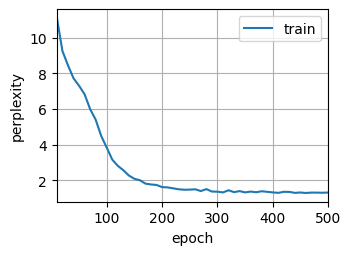

In [5]:
num_epochs, lr = 500, 1
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, device)